# NLP Exercises

We have five exercises in this section. The exercises are:
1. Build your own tokenizer, where you need to implement two functions to implement a tokenizer based on regular expression.
2. Get tags from Trump speech.
3. Get the nouns in the last 10 sentences from Trump's speech and find the nouns divided by sentencens. Use SpaCy.
4. Build your own Bag Of Words implementation using tokenizer created before.
5. Build a 5-gram model and clean up the results.

## Exercise 1. Build your own tokenizer

Build two different tokenizers:
- ``tokenize_sentence``: function tokenizing text into sentences,
- ``tokenize_word``: function tokenizing text into words.

In [ ]:
import re
from typing import List

def tokenize_words(text: str) -> list:
    """Tokenize text into words using regex.

    Parameters
    ----------
    text: str
            Text to be tokenized

    Returns
    -------
    List[str]
            List containing words tokenized from text

    """
    # from https://stackoverflow.com/questions/6202549/word-tokenization-using-python-regular-expressions
    pattern = r"[A-Z]{2,}(?![a-z])|[A-Z][a-z]+(?=[A-Z])|[\'\w\-]+"
    return re.findall(pattern, text)

def tokenize_sentence(text: str) -> list:
    """Tokenize text into words using regex.

    Parameters
    ----------
    text: str
            Text to be tokenized

    Returns
    -------
    List[str]
            List containing words tokenized from text

    """
    # https://stackoverflow.com/questions/3549075/regex-to-find-all-sentences-of-text
    pattern = r"([A-Z][^\.!?]*[\.!?])"
    sentences = re.findall(pattern, text)
    return [s.strip() for s in sentences if s]

text = "Here we go again. I was supposed to add this text later.\
Well, it's 10.p.m. here, and I'm actually having fun making this course. :o\
I hope you are getting along fine with this presentation, I really did try.\
And one last sentence, just so you can test you tokenizers better."

print("Tokenized sentences:")
print(tokenize_sentence(text))

print("Tokenized words:")
print(tokenize_words(text))

Tokenized sentences:
['Here we go again.', 'I was supposed to add this text later.', "Well, it's 10.", "I'm actually having fun making this course.", 'I hope you are getting along fine with this presentation, I really did try.', 'And one last sentence, just so you can test you tokenizers better.']
Tokenized words:
['Here', 'we', 'go', 'again', 'I', 'was', 'supposed', 'to', 'add', 'this', 'text', 'later', 'Well', "it's", '10', 'p', 'm', 'here', 'and', "I'm", 'actually', 'having', 'fun', 'making', 'this', 'course', 'oI', 'hope', 'you', 'are', 'getting', 'along', 'fine', 'with', 'this', 'presentation', 'I', 'really', 'did', 'try', 'And', 'one', 'last', 'sentence', 'just', 'so', 'you', 'can', 'test', 'you', 'tokenizers', 'better']


## Exercise 2. Get tags from Trump speech using NLTK

You should use the ``trump.txt`` file, read it and find the tags for each word. Use NLTK for it.

In [ ]:
import sys

# !{sys.executable} -m pip install nltk
# !{sys.executable} -m pip install spacy
# !python -m spacy download en_core_web_sm


In [38]:
import nltk
from nltk import pos_tag, word_tokenize

# nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger_eng')
# nltk.download('gutenberg')
# nltk.download('genesis')
# nltk.download('inaugural')
# nltk.download('nps_chat')
# nltk.download('webtext')
# nltk.download('treebank')


with open("../trump.txt", "r", encoding="utf-8") as file:
    trump = file.read()

tags = pos_tag(word_tokenize(trump))
print(tags[:50])

[('Thank', 'NNP'), ('you', 'PRP'), ('very', 'RB'), ('much', 'RB'), ('.', '.'), ('Mr.', 'NNP'), ('Speaker', 'NNP'), (',', ','), ('Mr.', 'NNP'), ('Vice', 'NNP'), ('President', 'NNP'), (',', ','), ('Members', 'NNP'), ('of', 'IN'), ('Congress', 'NNP'), (',', ','), ('the', 'DT'), ('First', 'NNP'), ('Lady', 'NNP'), ('of', 'IN'), ('the', 'DT'), ('United', 'NNP'), ('States', 'NNPS'), (',', ','), ('and', 'CC'), ('citizens', 'NNS'), ('of', 'IN'), ('America', 'NNP'), (':', ':'), ('Tonight', 'NN'), (',', ','), ('as', 'IN'), ('we', 'PRP'), ('mark', 'VBP'), ('the', 'DT'), ('conclusion', 'NN'), ('of', 'IN'), ('our', 'PRP$'), ('celebration', 'NN'), ('of', 'IN'), ('Black', 'NNP'), ('History', 'NNP'), ('Month', 'NNP'), (',', ','), ('we', 'PRP'), ('are', 'VBP'), ('reminded', 'VBN'), ('of', 'IN'), ('our', 'PRP$'), ('Nation', 'NN')]


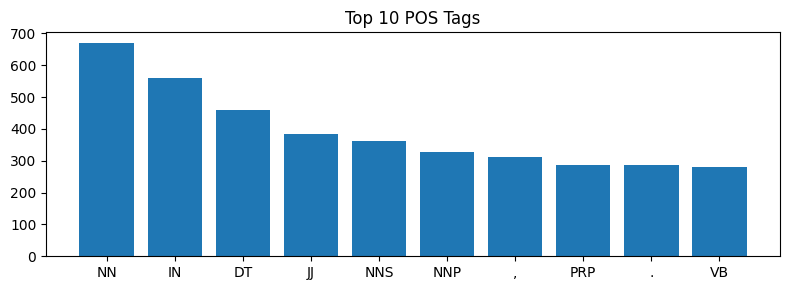

In [13]:
import matplotlib.pyplot as plt
from collections import Counter

labels, values = zip(*Counter(tag for _, tag in tags).most_common(10))

plt.figure(figsize=(8, 3))
plt.bar(labels, values)
plt.title("Top 10 POS Tags")
plt.tight_layout()
plt.show()

## Exercise 3. Get the nouns in the last 10 sentences from Trump's speech and find the nouns divided by sentencens. Use SpaCy.

Please use Python list features to get the last 10 sentences and display nouns from it.

In [20]:
import spacy

with open("../trump.txt", "r", encoding="utf-8") as file:
    trump = file.read()

nlp = spacy.load("en_core_web_sm")
last_10 = list(nlp(trump).sents)[-10:]

for i, sent in enumerate(last_10, 1):
    nouns = [t.text for t in sent if t.pos_ == "NOUN"]
    print(f"{i}. {sent.text.strip()}")
    print(nouns)

1. When we fulfill this vision, when we celebrate our 250 years of glorious freedom, we will look back on tonight as when this new chapter of American greatness began.
['vision', 'years', 'freedom', 'tonight', 'chapter', 'greatness']
2. The time for small thinking is over.
['time', 'thinking']
3. The time for trivial fights is behind us.
['time', 'fights']
4. We just need the courage to share the dreams that fill our hearts, the bravery to express the hopes that stir our souls, and the confidence to turn those hopes and those dreams into action.
['courage', 'dreams', 'hearts', 'bravery', 'hopes', 'souls', 'confidence', 'hopes', 'dreams', 'action']
5. From now on, America will be empowered by our aspirations, not burdened by our fears; inspired by the future, not bound by failures of the past; and guided by our vision, not blinded by our doubts.
['aspirations', 'fears', 'future', 'failures', 'past', 'vision', 'doubts']
6. I am asking all citizens to embrace this renewal of the American 

## Exercise 4. Build your own Bag Of Words implementation using tokenizer created before 

You need to implement following methods:

- ``fit_transform`` - gets a list of strings and returns matrix with it's BoW representation
- ``get_features_names`` - returns list of words corresponding to columns in BoW

In [21]:
import numpy as np
import spacy

class BagOfWords:
    """Basic BoW implementation."""

    __nlp = spacy.load("en_core_web_sm")

    def __init__(self):
        self.__bow_list = []

    def fit_transform(self, corpus: list):
        """Transform list of strings into BoW array.

        Parameters
        ----------
        corpus: List[str]
                Corpus of texts to be transforrmed

        Returns
        -------
        np.array
                Matrix representation of BoW

        """
        tokenized = []
        vocab = set()

        for text in corpus:
            words = [t.lemma_.lower() for t in self.__nlp(text) if t.is_alpha]
            tokenized.append(words)
            vocab.update(words)

        self.__bow_list = sorted(vocab)
        word_to_idx = {w: i for i, w in enumerate(self.__bow_list)}

        X = np.zeros((len(corpus), len(self.__bow_list)), dtype=int)
        for row, words in enumerate(tokenized):
            for w in words:
                X[row, word_to_idx[w]] += 1

        return X

    def get_feature_names(self) -> list:
        """Return words corresponding to columns of matrix.

        Returns
        -------
        List[str]
                Words being transformed by fit function

        """
        return self.__bow_list

corpus = [
     'Bag Of Words is based on counting',
     'words occurences throughout multiple documents.',
     'This is the third document.',
     'As you can see most of the words occur only once.',
     'This gives us a pretty sparse matrix, see below. Really, see below',
]

vectorizer = BagOfWords()

X = vectorizer.fit_transform(corpus)
print(X)

vectorizer.get_feature_names()
len(vectorizer.get_feature_names())

[[0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0]
 [0 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 1 0 1]
 [1 0 0 0 0 2 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 2 1 0 0 1 0 1 0 0 0]]


31

## Exercise 5. Build a 5-gram model and clean up the results.

There are three tasks to do:
1. Use 5-gram model instead of 3.
2. Change to capital letter each first letter of a sentence.
3. Remove the whitespace between the last word in a sentence and . ! or ?.

Hint: for 2. and 3. implement a function called ``clean_generated()`` that takes the generated text and fix both issues at once. It could be easier to fix the text after it's generated rather then doing some changes in the while loop.

In [41]:
from nltk.book import *

wall_street = text7.tokens

import re

tokens = wall_street

def cleanup():
    compiled_pattern = re.compile("^[a-zA-Z0-9.!?]")
    clean = list(filter(compiled_pattern.match,tokens))
    return clean
tokens = cleanup()

def build_ngrams():
    ngrams = []
    for i in range(len(tokens)-N+1):
        ngrams.append(tokens[i:i+N])
    return ngrams

def ngram_freqs(ngrams):
    counts = {}

    for ngram in ngrams:
        token_seq  = SEP.join(ngram[:-1])
        last_token = ngram[-1]

        if token_seq not in counts:
            counts[token_seq] = {}

        if last_token not in counts[token_seq]:
            counts[token_seq][last_token] = 0

        counts[token_seq][last_token] += 1;

    return counts

def next_word(text, N, counts):

    token_seq = SEP.join(text.split()[-(N-1):]);
    choices = counts[token_seq].items();

    total = sum(weight for choice, weight in choices)
    r = random.uniform(0, total)
    upto = 0
    for choice, weight in choices:
        upto += weight;
        if upto > r: return choice
    assert False # should not reach here

In [46]:
import random

def clean_generated(text):
    text = re.sub(r"\s+([.!?])", r"\1", text)
    return re.sub(
        r"(^|(?<=[.!?]\s))([a-z])",
        lambda m: m.group(1) + m.group(2).upper(),
        text.strip(),
    )

N=5

SEP=" "

sentence_count=5

ngrams = build_ngrams()
start_seq=None

counts = ngram_freqs(ngrams)

if start_seq is None: start_seq = random.choice(list(counts.keys()))
generated = start_seq.lower();

sentences = 0
while sentences < sentence_count:
    generated += SEP + next_word(generated, N, counts)
    sentences += 1 if generated.endswith(('.','!', '?')) else 0

generated = clean_generated(generated)
print(generated)

Quarter of black voters disapprove of Mr. Bush handling of his job only 15 have a negative view of his spouse. The statistics imply that three-quarters of blacks approve of Mr. Bush job performance and 85 of blacks approve of Mr. Bush job performance and 85 of blacks approve of Mr.
